# VLM Visual Agnosia Experiment

**Research Question:** Do VLMs show human-like patterns of object recognition failure under degraded or fragmented visual input, mirroring the dissociations seen in apperceptive vs. associative visual agnosia?

**Hypothesis:** VLMs will pass degraded line drawings (where bottom-up feature matching is possible) but fail Mooney images (which require top-down global form completion before any recognition is possible). This would suggest their visual processing is texture/feature-based rather than genuinely perceptual, consistent with Marjieh et al.'s finding that visual input does not add perceptual structure beyond what language already captures.

## 1. Setup

In [1]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import base64
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

# All Gemini models (gemini-2.5-pro, gemini-3-flash-preview, gemini-3.1-flash-lite-preview)
# return 400 on this endpoint despite being listed at /v1/models.
# Confirmed working vision models:
MODELS = [
    "claude-sonnet-4-5",   # Anthropic
    "gpt-5.4",             # OpenAI
]

print("Setup complete.")
print("Active models:", MODELS)

Setup complete.
Active models: ['claude-sonnet-4-5', 'gpt-5.4']


## 2. Load Stimuli

In [2]:
def load_stimuli(stimuli_dir="stimuli"):
    """
    Load stimuli from all conditions:
      - mooney/          standard Mooney (S&V line drawings)
      - mooney_inverted/ contamination control
      - degraded_25/     25% of line pixels removed
      - degraded_50/     50% of line pixels removed
      - degraded_75/     75% of line pixels removed
      - degraded_90/     90% of line pixels removed
    Returns a list of dicts: {label, condition, path}
    """
    conditions = {
        "mooney":       os.path.join(stimuli_dir, "mooney"),
        "mooney_inv":   os.path.join(stimuli_dir, "mooney_inverted"),
        "degraded_25":  os.path.join(stimuli_dir, "degraded_25"),
        "degraded_50":  os.path.join(stimuli_dir, "degraded_50"),
        "degraded_75":  os.path.join(stimuli_dir, "degraded_75"),
        "degraded_90":  os.path.join(stimuli_dir, "degraded_90"),
    }
    label_sets = []
    for cdir in conditions.values():
        label_sets.append({os.path.splitext(f)[0] for f in os.listdir(cdir)
                           if f.lower().endswith('.png')})
    matched = sorted(set.intersection(*label_sets))
    print(f"Found {len(matched)} objects matched across all {len(conditions)} conditions.")

    stimuli = []
    for label in matched:
        for cname, cdir in conditions.items():
            stimuli.append({"label": label, "condition": cname,
                            "path": os.path.join(cdir, f"{label}.png")})
    print(f"Total trials: {len(stimuli)}")
    return stimuli


def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


stimuli = load_stimuli()
pd.DataFrame(stimuli).groupby("condition").size().rename("n_trials")


Found 260 objects matched across all 6 conditions.
Total trials: 1560


condition
degraded_25    260
degraded_50    260
degraded_75    260
degraded_90    260
mooney         260
mooney_inv     260
Name: n_trials, dtype: int64

## 3. Prompting

Simple forced-choice prompt — model names the object in one word or short phrase. Same prompt used across all models and conditions (controls for autoregressive artifact confound).

In [3]:
SYSTEM_PROMPT = "You are participating in an object recognition experiment. Respond with only the name of the object you see — a single word or short noun phrase. Do not describe the image. Do not say you are unsure. Just name the object."

USER_PROMPT = "What object is in this image?"

# Synonym map: label (no underscores) -> list of accepted alternatives
SYNONYMS = {
    "garbage can":    ["trash can", "rubbish bin", "waste bin", "dustbin"],
    "gun":            ["revolver", "pistol", "firearm", "handgun"],
    "kettle":         ["teapot"],
    "pot":            ["saucepan", "cooking pot"],
    "pocketbook":     ["handbag", "purse", "wallet"],
    "wineglass":      ["goblet", "wine glass"],
    "sea horse":      ["seahorse"],
    "roller skate":   ["roller skates"],
    "tennis racket":  ["tennis racquet", "racket", "racquet"],
    "record player":  ["turntable", "gramophone", "phonograph"],
    "jacket":         ["coat", "blazer"],
    "seal":           ["sea lion"],
}


def query_model(model, image_path, system_prompt=SYSTEM_PROMPT, user_prompt=USER_PROMPT):
    """
    Send a single image to a VLM and return its text response.
    """
    image_data = encode_image(image_path)
    ext = os.path.splitext(image_path)[-1].lower().replace(".", "")
    mime = "image/jpeg" if ext in ("jpg", "jpeg") else "image/png"

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{image_data}"}},
                    {"type": "text", "text": user_prompt}
                ]
            }
        ],
        reasoning_effort=None
    )

    return response.choices[0].message.content.strip().lower()


def is_correct(response, true_label):
    """
    Check if the model's response matches the true object label.
    - Normalizes underscores to spaces before comparison
    - Accepts known synonyms
    - Rejects hallucinations (responses > 8 words — model produced unrelated text)
    """
    resp = response.lower().strip()
    label = true_label.lower().replace("_", " ").strip()

    # Hallucination guard: valid object names are short
    if len(resp.split()) > 8:
        return False

    if label in resp:
        return True

    for syn in SYNONYMS.get(label, []):
        if syn.lower() in resp:
            return True

    return False


print("Prompting functions ready.")

Prompting functions ready.


## 4. Run Experiment

In [4]:
# Experiment 1 results — already collected, load from checkpoint
results_df = pd.read_csv("results_checkpoint.csv")
results_df["correct"] = results_df.apply(lambda r: is_correct(r["response"], r["label"]), axis=1)
print(f"Loaded {len(results_df)} trials")
results_df.groupby(["model", "condition"])["correct"].mean().unstack().round(3)

Loaded 3120 trials


condition,degraded_25,degraded_50,degraded_75,degraded_90,mooney,mooney_inv
model,,,,,,
claude-sonnet-4-5,0.912,0.815,0.65,0.488,0.819,0.762
gpt-5.4,0.931,0.896,0.85,0.804,0.796,0.731


## 5. Analysis & Plots

Loading from: results_checkpoint.csv


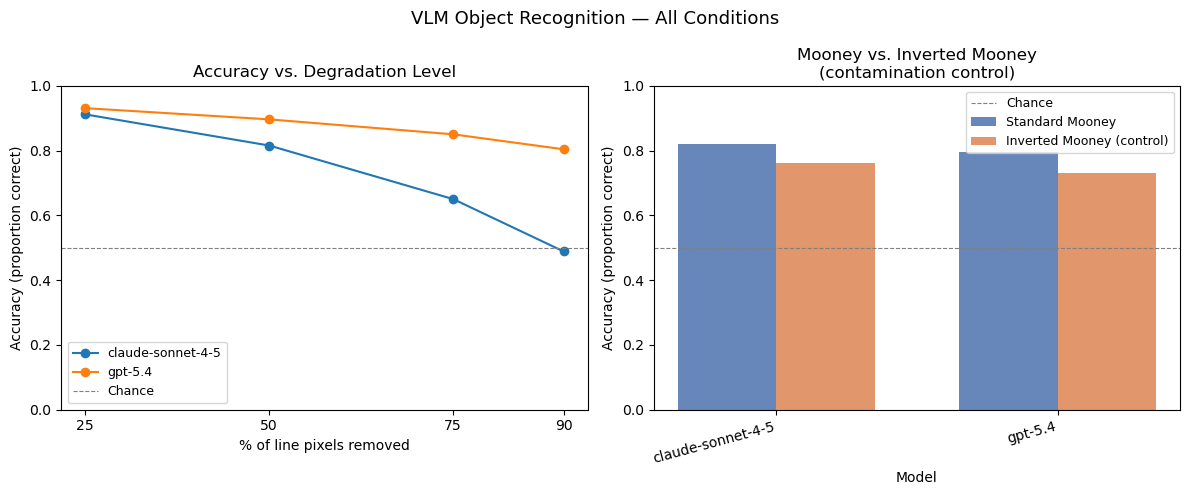

                model    condition  accuracy
0   claude-sonnet-4-5  degraded_25  0.911538
1   claude-sonnet-4-5  degraded_50  0.815385
2   claude-sonnet-4-5  degraded_75  0.650000
3   claude-sonnet-4-5  degraded_90  0.488462
4   claude-sonnet-4-5       mooney  0.819231
5   claude-sonnet-4-5   mooney_inv  0.761538
6             gpt-5.4  degraded_25  0.930769
7             gpt-5.4  degraded_50  0.896154
8             gpt-5.4  degraded_75  0.850000
9             gpt-5.4  degraded_90  0.803846
10            gpt-5.4       mooney  0.796154
11            gpt-5.4   mooney_inv  0.730769


In [5]:
# Load results — use checkpoint file if final results.csv not yet saved
results_file = "results.csv" if os.path.exists("results.csv") else "results_checkpoint.csv"
print(f"Loading from: {results_file}")
results_df = pd.read_csv(results_file)

# Rescore with current is_correct (applies hallucination guard retroactively)
results_df["correct"] = results_df.apply(
    lambda r: is_correct(r["response"], r["label"]), axis=1
)

def plot_accuracy(results_df):
    """
    Two-panel figure:
      Left:  accuracy curve across degradation levels (25/50/75/90%)
      Right: bar chart for Mooney vs. inverted Mooney
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]
    models = summary["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: degradation curve ---
    ax = axes[0]
    degraded_conditions = ["degraded_25", "degraded_50", "degraded_75", "degraded_90"]
    x_vals = [25, 50, 75, 90]
    for model in models:
        y_vals = [
            summary[(summary["model"] == model) & (summary["condition"] == c)]["accuracy"].values[0]
            for c in degraded_conditions
        ]
        ax.plot(x_vals, y_vals, marker="o", label=model.split("/")[-1])
    ax.set_xlabel("% of line pixels removed")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Accuracy vs. Degradation Level")
    ax.set_xticks(x_vals)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
    ax.legend(fontsize=9)

    # --- Right: Mooney vs. inverted Mooney ---
    ax = axes[1]
    mooney_conditions = ["mooney", "mooney_inv"]
    x = np.arange(len(models))
    width = 0.35
    colors = ["#4C72B0", "#DD8452"]
    for i, cond in enumerate(mooney_conditions):
        vals = [
            summary[(summary["model"] == m) & (summary["condition"] == cond)]["accuracy"].values[0]
            for m in models
        ]
        label = "Standard Mooney" if cond == "mooney" else "Inverted Mooney (control)"
        ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.85)
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Mooney vs. Inverted Mooney\n(contamination control)")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
    ax.legend(fontsize=9)

    plt.suptitle("VLM Object Recognition — All Conditions", fontsize=13)
    plt.tight_layout()
    plt.savefig("accuracy_by_condition.png", dpi=150)
    plt.show()
    return summary


summary = plot_accuracy(results_df)
print(summary.to_string())

## 6. Human Comparison

Human benchmarks from the literature (used as directional baselines):

- **Mooney images (objects):** ~34% spontaneous recognition (Snodgrass & Corwin, 1988)
- **Degraded line drawings:** ~63% at 25% removal → ~15% at 90% removal (Snodgrass & Corwin, 1988; Koch et al., 1995)

**Limitation:** Human norms were collected using a different degradation method on the same S&V stimuli. The comparison is directional, not exact. Acknowledged in the Open Questions slide.

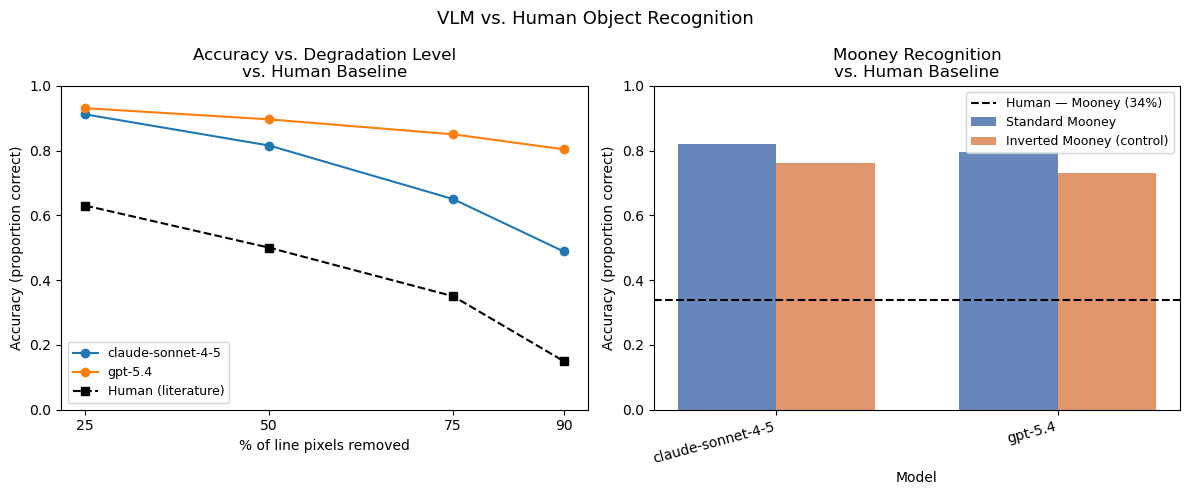

In [6]:
def plot_with_human_baseline(results_df,
                             human_mooney=0.34,
                             human_degraded={25: 0.63, 50: 0.50, 75: 0.35, 90: 0.15}):
    """
    Two-panel figure with human baselines overlaid.

    Human baselines (from Snodgrass & Corwin, 1988; Koch et al., 1995):
      - Mooney objects:         ~34% spontaneous recognition
      - Degraded 75% removed:  ~35% (threshold fragmentation)
      - Degraded 50% removed:  ~50% (interpolated)
      - Degraded 25% removed:  ~63% (easier items, Koch et al.)
      - Degraded 90% removed:  ~15% (extrapolated)
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]
    models = summary["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Left: degradation curve with human baseline ---
    ax = axes[0]
    degraded_conditions = ["degraded_25", "degraded_50", "degraded_75", "degraded_90"]
    x_vals = [25, 50, 75, 90]
    for model in models:
        y_vals = [
            summary[(summary["model"] == model) & (summary["condition"] == c)]["accuracy"].values[0]
            for c in degraded_conditions
        ]
        ax.plot(x_vals, y_vals, marker="o", label=model.split("/")[-1])
    human_y = [human_degraded[x] for x in x_vals]
    ax.plot(x_vals, human_y, marker="s", linestyle="--", color="black", label="Human (literature)")
    ax.set_xlabel("% of line pixels removed")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Accuracy vs. Degradation Level\nvs. Human Baseline")
    ax.set_xticks(x_vals)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    # --- Right: Mooney bar with human baseline ---
    ax = axes[1]
    mooney_conditions = ["mooney", "mooney_inv"]
    x = np.arange(len(models))
    width = 0.35
    colors = ["#4C72B0", "#DD8452"]
    for i, cond in enumerate(mooney_conditions):
        vals = [
            summary[(summary["model"] == m) & (summary["condition"] == cond)]["accuracy"].values[0]
            for m in models
        ]
        label = "Standard Mooney" if cond == "mooney" else "Inverted Mooney (control)"
        ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.85)
    ax.axhline(human_mooney, color="black", linestyle="--", linewidth=1.5,
               label=f"Human — Mooney ({human_mooney:.0%})")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Mooney Recognition\nvs. Human Baseline")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

    plt.suptitle("VLM vs. Human Object Recognition", fontsize=13)
    plt.tight_layout()
    plt.savefig("accuracy_with_human_baseline.png", dpi=150)
    plt.show()


plot_with_human_baseline(results_df)

## 7. Error Type Analysis

For each incorrect trial, we classify the error type:
- **hallucination** — response >8 words (model produced unrelated text instead of an object name)
- **confabulation** — response is an unrelated object (false percept; apperceptive failure)
- **semantic_neighbor** — response is a categorically similar object (associative failure)
- **part_whole** — response names a part or superordinate of the target

Error counts by condition and type:
error_type   confabulation  part_whole  semantic_neighbor
condition                                                
degraded_25             39           1                  1
degraded_50             72           0                  3
degraded_75            126           1                  3
degraded_90            182           0                  2
mooney                  96           2                  2
mooney_inv             127           0                  5


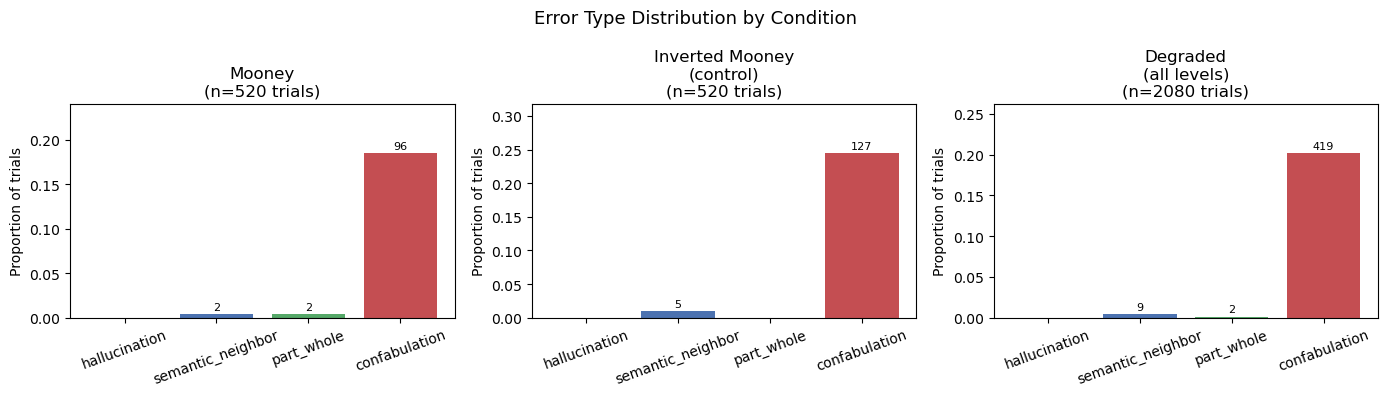

In [7]:
# Semantic neighbor sets — objects that are easily confused
SEMANTIC_NEIGHBORS = {
    "seal":          ["walrus", "sea lion", "otter"],
    "toe":           ["finger", "thumb"],
    "thumb":         ["finger", "toe"],
    "mouse":         ["rat", "hamster", "gerbil"],
    "lettuce":       ["cabbage", "spinach", "salad"],
    "lips":          ["mouth"],
    "jacket":        ["coat", "shirt", "blazer"],
    "swan":          ["goose", "duck", "bird"],
    "sheep":         ["goat", "lamb", "cow"],
    "ring":          ["bracelet", "watch", "pocket watch"],
    "pencil":        ["pen", "marker", "crayon"],
    "paintbrush":    ["brush", "broom"],
    "tennis racket": ["badminton racket", "racket"],
    "thimble":       ["cup", "toaster"],
}

# Body part / part-whole confusion set
PART_WHOLE = {
    "nose":  ["face", "head"],
    "thumb": ["finger", "hand"],
    "toe":   ["finger", "foot"],
    "lips":  ["face", "mouth"],
    "hair":  ["head"],
    "leg":   ["body"],
}


def classify_error(response, true_label):
    """
    For an incorrect trial, classify the error type.
    Returns: 'hallucination', 'semantic_neighbor', 'part_whole', or 'confabulation'
    """
    resp = response.lower().strip()
    label = true_label.lower().replace("_", " ").strip()

    # Hallucination: response is too long to be an object name
    if len(resp.split()) > 8:
        return "hallucination"

    if label in PART_WHOLE:
        for pw in PART_WHOLE[label]:
            if pw in resp:
                return "part_whole"

    if label in SEMANTIC_NEIGHBORS:
        for neighbor in SEMANTIC_NEIGHBORS[label]:
            if neighbor in resp:
                return "semantic_neighbor"

    return "confabulation"


results_df = pd.read_csv(results_file)

# Rescore with hallucination guard
results_df["correct"] = results_df.apply(
    lambda r: is_correct(r["response"], r["label"]), axis=1
)

errors = results_df[results_df["correct"] == False].copy()
errors["error_type"] = errors.apply(
    lambda r: classify_error(r["response"], r["label"]), axis=1
)

print("Error counts by condition and type:")
print(errors.groupby(["condition", "error_type"]).size().unstack(fill_value=0))

# Plot: 3 panels — mooney, mooney_inv, degraded (all levels aggregated)
errors["condition_group"] = errors["condition"].apply(
    lambda c: "degraded (all levels)" if c.startswith("degraded") else c
)

results_df["condition_group"] = results_df["condition"].apply(
    lambda c: "degraded (all levels)" if c.startswith("degraded") else c
)

plot_conditions = ["mooney", "mooney_inv", "degraded (all levels)"]
condition_labels = ["Mooney", "Inverted Mooney\n(control)", "Degraded\n(all levels)"]
error_types = ["hallucination", "semantic_neighbor", "part_whole", "confabulation"]
colors = ["#8B0000", "#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, cond, cond_label in zip(axes, plot_conditions, condition_labels):
    subset_errors = errors[errors["condition_group"] == cond]
    total = len(results_df[results_df["condition_group"] == cond])
    counts = [len(subset_errors[subset_errors["error_type"] == t]) for t in error_types]
    bars = ax.bar(error_types, [c / total for c in counts], color=colors)
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    str(count), ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{cond_label}\n(n={total} trials)")
    ax.set_ylabel("Proportion of trials")
    y_max = max([c / total for c in counts] + [0.05]) * 1.3
    ax.set_ylim(0, y_max)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Error Type Distribution by Condition", fontsize=13)
plt.tight_layout()
plt.savefig("error_type_analysis.png", dpi=150)
plt.show()

## 8. Experiment 2 — Priming + Hard Mooney

**Manipulation:** Each trial sends two images in one message:
1. The `degraded_25` version (primer — visible enough to identify)
2. The `mooney_hard` version (blur=4.0, harder two-tone)

**Question:** Does seeing the degraded version prime VLM recognition of the harder Mooney, as it does for humans?

- **Human priming effect:** Recognition of Mooney images improves dramatically after seeing the original/degraded version — once you see it, you can't un-see it (Gregory, 1970; Moore & Cavanagh, 1998). This reflects top-down feedback from stored object representations.
- **If VLMs show large priming boost** → suggests top-down feedback or context integration
- **If VLMs show no priming boost** → feedforward feature matching; priming requires mechanisms VLMs lack

Conditions:
- `mooney_hard_unprimed` — hard Mooney alone (control)
- `mooney_hard_primed` — degraded_25 shown first, then hard Mooney

In [ ]:
PRIMING_SYSTEM_PROMPT = "You are participating in an object recognition experiment. Respond with only the name of the object you see — a single word or short noun phrase. Do not describe the image. Do not say you are unsure. Just name the object."

PRIMED_USER_PROMPT = "Here is a partially degraded version of an object. Now, what object is shown in the second image?"
UNPRIMED_USER_PROMPT = "What object is in this image?"


def query_model_primed(model, primer_path, mooney_path):
    """
    Send primer image (degraded_25) followed by hard Mooney in one message.
    Tests whether seeing the degraded version boosts recognition of the Mooney.
    """
    primer_data = encode_image(primer_path)
    mooney_data = encode_image(mooney_path)

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": PRIMING_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{primer_data}"}},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{mooney_data}"}},
                    {"type": "text", "text": PRIMED_USER_PROMPT}
                ]
            }
        ],
        reasoning_effort=None
    )
    return response.choices[0].message.content.strip().lower()


def query_model_unprimed(model, mooney_path):
    """Send hard Mooney alone (unprimed control)."""
    mooney_data = encode_image(mooney_path)
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": PRIMING_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{mooney_data}"}},
                    {"type": "text", "text": UNPRIMED_USER_PROMPT}
                ]
            }
        ],
        reasoning_effort=None
    )
    return response.choices[0].message.content.strip().lower()


def run_priming_experiment(models, stimuli_dir="stimuli",
                           checkpoint_file="results_priming_checkpoint.csv"):
    """
    Run Experiment 2: primed vs. unprimed hard Mooney.
    Only runs the 2 new conditions; does not repeat Experiment 1 trials.
    Checkpoints after every trial.
    """
    degraded_dir = os.path.join(stimuli_dir, "degraded_25")
    mooney_dir   = os.path.join(stimuli_dir, "mooney_hard")

    labels = sorted([os.path.splitext(f)[0] for f in os.listdir(mooney_dir)
                     if f.lower().endswith('.png')])
    print(f"Experiment 2: {len(labels)} objects × 2 conditions × {len(models)} models "
          f"= {len(labels)*2*len(models)} trials")

    # Load checkpoint
    if os.path.exists(checkpoint_file):
        existing = pd.read_csv(checkpoint_file)
        done = set(zip(existing["model"], existing["label"], existing["condition"]))
        results = existing.to_dict("records")
        print(f"Resuming from checkpoint: {len(results)} trials already done")
    else:
        done, results = set(), []

    for model in models:
        print(f"\nModel: {model}")
        for label in tqdm(labels):
            mooney_path  = os.path.join(mooney_dir, f"{label}.png")
            primer_path  = os.path.join(degraded_dir, f"{label}.png")

            # Unprimed condition
            if (model, label, "mooney_hard_unprimed") not in done:
                resp = query_model_unprimed(model, mooney_path)
                results.append({
                    "model": model, "label": label,
                    "condition": "mooney_hard_unprimed",
                    "response": resp,
                    "correct": is_correct(resp, label)
                })
                done.add((model, label, "mooney_hard_unprimed"))
                pd.DataFrame(results).to_csv(checkpoint_file, index=False)

            # Primed condition
            if (model, label, "mooney_hard_primed") not in done:
                resp = query_model_primed(model, primer_path, mooney_path)
                results.append({
                    "model": model, "label": label,
                    "condition": "mooney_hard_primed",
                    "response": resp,
                    "correct": is_correct(resp, label)
                })
                done.add((model, label, "mooney_hard_primed"))
                pd.DataFrame(results).to_csv(checkpoint_file, index=False)

    df = pd.DataFrame(results)
    df.to_csv("results_priming.csv", index=False)
    print(f"\nDone. Saved to results_priming.csv")
    return df


priming_df = run_priming_experiment(MODELS)
priming_df.groupby(["model", "condition"])["correct"].mean().unstack()

Experiment 2: 260 objects × 2 conditions × 2 models = 1040 trials

Model: claude-sonnet-4-5


  4%|▍         | 11/260 [00:26<09:39,  2.33s/it]

In [8]:
def plot_priming_effect(priming_df,
                        human_unprimed=0.20,
                        human_primed=0.65):
    summary = priming_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    models = priming_df["model"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    x = np.arange(len(models))
    width = 0.35
    conditions = ["mooney_hard_unprimed", "mooney_hard_primed"]
    colors = ["#4C72B0", "#2ca02c"]
    labels_bar = ["Hard Mooney (unprimed)", "Hard Mooney (primed)"]

    for i, (cond, color, lbl) in enumerate(zip(conditions, colors, labels_bar)):
        vals = [
            summary[(summary["model"] == m) & (summary["condition"] == cond)]["correct"].values[0]
            for m in models
        ]
        bars = ax.bar(x + i * width, vals, width, label=lbl, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{v:.0%}", ha="center", va="bottom", fontsize=9)

    ax.axhline(human_unprimed, color="#4C72B0", linestyle="--", linewidth=1.2,
               label=f"Human unprimed (~{human_unprimed:.0%})")
    ax.axhline(human_primed, color="#2ca02c", linestyle="--", linewidth=1.2,
               label=f"Human primed (~{human_primed:.0%})")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Priming Effect on Hard Mooney Recognition")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    ax = axes[1]
    deltas = []
    for m in models:
        unp = summary[(summary["model"] == m) & (summary["condition"] == "mooney_hard_unprimed")]["correct"].values[0]
        pri = summary[(summary["model"] == m) & (summary["condition"] == "mooney_hard_primed")]["correct"].values[0]
        deltas.append(pri - unp)

    human_delta = human_primed - human_unprimed
    bar_colors = ["#4C72B0" if d >= 0 else "#C44E52" for d in deltas]
    bars = ax.bar([m.split("/")[-1] for m in models], deltas, color=bar_colors, alpha=0.85)
    for bar, d in zip(bars, deltas):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.01 if d >= 0 else -0.03),
                f"{d:+.0%}", ha="center", va="bottom", fontsize=10)

    ax.axhline(human_delta, color="black", linestyle="--", linewidth=1.5,
               label=f"Human priming boost (~{human_delta:+.0%})")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel("Priming boost (primed − unprimed accuracy)")
    ax.set_title("Priming Effect Size
vs. Human Expectation")
    ax.set_ylim(-0.2, 0.7)
    ax.legend(fontsize=9)

    plt.suptitle("Experiment 2: Visual Priming in VLMs", fontsize=13)
    plt.tight_layout()
    plt.savefig("priming_effect.png", dpi=150)
    plt.show()

    print("
Priming effect summary:")
    for m, d in zip(models, deltas):
        print(f"  {m}: {d:+.1%} (human: {human_delta:+.1%})")


priming_file = "results_priming.csv" if os.path.exists("results_priming.csv") else "results_priming_checkpoint.csv"
print(f"Loading from: {priming_file}")
priming_df = pd.read_csv(priming_file)
priming_df["correct"] = priming_df.apply(lambda r: is_correct(r["response"], r["label"]), axis=1)
plot_priming_effect(priming_df)


SyntaxError: unterminated string literal (detected at line 57) (2364930338.py, line 57)